In [1]:
# ── Imports ──
# HR binary model using logistic regression — purpose built for binary outcomes
# Directly models P(HR >= 1) without Poisson intermediate step
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine

In [2]:
# ── Load base dataset from database ──
# Same query as v4/v5 but now pulling hr column from witt_game_logs
with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.whip,
            p.k_per_9,
            p.era_last5,
            p.whip_last5,
            p.era_vs_rhb,
            b.bullpen_era,
            b.bullpen_whip,
            pf.park_factor,
            pf.park_factor_hr
        FROM witt_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN bullpen_stats b ON w.game_id = b.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 118
                 ELSE w.opponent_id
            END = pf.team_id
        )
        ORDER BY w.date
    """), conn)

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb']].head(10))

Base dataset: (626, 18)
         date  hr  tb
0  2022-04-07   0   2
1  2022-04-09   0   0
2  2022-04-10   0   2
3  2022-04-11   0   0
4  2022-04-12   0   0
5  2022-04-14   0   3
6  2022-04-15   0   0
7  2022-04-16   0   2
8  2022-04-19   0   0
9  2022-04-20   0   0


In [3]:
# ── HR distribution and base rate ──
# Understand the baseline before modeling
# This is the number you compare to the book's implied probability
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

# Break-even odds — book must offer better than this for base rate edge
breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"Book must offer better than {breakeven:.0f} for base rate edge")

HR distribution:
hr
0    527
1     93
2      6
Name: count, dtype: int64

Games with 0 HR:  0.842
Games with 1+ HR: 0.158 (15.8% of games)
Games with 2+ HR: 0.010

Break-even American odds: -19
Book must offer better than -19 for base rate edge


In [4]:
# ── Pull Statcast data via pybaseball ──
# Pitch-level data for Witt 2022-2025
# Barrel rate is directly predictive of HR — a barreled ball becomes HR ~50% of the time
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=677951)
print(f"Statcast raw: {statcast_raw.shape}")

Pulling Statcast data...
Gathering Player Data
Statcast raw: (10689, 118)


In [5]:
# ── Aggregate Statcast to game level ──
# Filter to batted balls only — NaN launch_speed = pitch not put in play
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    max_exit_velo=('launch_speed', 'max'),
    # Barrel = launch_speed_angle 6 — optimal exit velo + launch angle
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    # Hard hit = 95mph+ exit velocity
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")

Game-level Statcast: (641, 8)


In [6]:
# ── Rolling Statcast features ──
# shift(1) prevents current game leaking into its own prediction
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_7']  = game_stats['avg_exit_velo'].shift(1).rolling(7,  min_periods=3).mean()
game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_7']    = game_stats['barrel_rate'].shift(1).rolling(7,  min_periods=3).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_7']  = game_stats['hard_hit_rate'].shift(1).rolling(7,  min_periods=3).mean()

print(game_stats[['game_date', 'barrel_rate', 'barrel_rate_7']].head(10))

    game_date  barrel_rate  barrel_rate_7
0  2022-04-07          0.0            NaN
1  2022-04-09          0.0            NaN
2  2022-04-10          0.0            NaN
3  2022-04-11          0.0            0.0
4  2022-04-12          0.0            0.0
5  2022-04-14          0.0            0.0
6  2022-04-15          0.0            0.0
7  2022-04-16          0.0            0.0
8  2022-04-19          0.0            0.0
9  2022-04-20          0.0            0.0


In [7]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_7', 'avg_exit_velo_15',
                'barrel_rate_7', 'barrel_rate_15', 'hard_hit_rate_7']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_7', 'barrel_rate_7']].isnull().sum())

After merge: (626, 24)
avg_exit_velo_7    3
barrel_rate_7      3
dtype: int64


In [8]:
# ── Feature engineering — HR rolling features ──
# Rolling HR rate — is he in a hot power stretch?
df = df.sort_values('date').reset_index(drop=True)

df['hr_avg_7']  = df['hr'].shift(1).rolling(7,  min_periods=3).mean()
df['hr_avg_15'] = df['hr'].shift(1).rolling(15, min_periods=7).mean()
df['hr_lag1']   = df['hr'].shift(1)
df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Drop rows missing any rolling features
df_model = df.dropna(subset=['hr_avg_7', 'hr_avg_15', 'hr_lag1',
                              'avg_exit_velo_7', 'barrel_rate_7']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")
print(df_model[['date', 'hr', 'hr_avg_7', 'barrel_rate_7']].head(10))

Model dataset: (619, 29)
        date  hr  hr_avg_7  barrel_rate_7
0 2022-04-16   0       0.0            0.0
1 2022-04-19   0       0.0            0.0
2 2022-04-20   0       0.0            0.0
3 2022-04-21   0       0.0            0.0
4 2022-04-22   0       0.0            0.0
5 2022-04-23   0       0.0            0.0
6 2022-04-24   0       0.0            0.0
7 2022-04-26   0       0.0            0.0
8 2022-04-27   0       0.0            0.0
9 2022-04-28   0       0.0            0.0


In [9]:
# ── Define features and binary target ──
# Target: did Witt hit at least one HR? (1 = yes, 0 = no)
# Logistic regression directly models this probability
FEATURES = [
    # Witt recent HR form
    'hr_lag1',
    'hr_avg_7',
    'hr_avg_15',
    # Witt contact quality — barrel rate directly predicts HR
    'avg_exit_velo_7',
    'avg_exit_velo_15',
    'barrel_rate_7',
    'barrel_rate_15',
    'hard_hit_rate_7',
    # Game context
    'is_home',
    'pitcher_r',
    # Starter stats
    'era',
    'whip',
    'k_per_9',
    'era_last5',
    'era_vs_rhb',
    # Bullpen
    'bullpen_era',
    # Park — park_factor_hr specifically relevant for HR
    'park_factor',
    'park_factor_hr',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")

Features: 18
Dataset: (619, 18)
HR rate: 0.160 (99 HR games out of 619)


In [10]:
# ── Scale features ──
# Logistic regression is a linear model — sensitive to feature scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [11]:
# ── Baseline ──
# Naive model: always predict no HR (majority class)
# Accuracy of always predicting no HR = 1 - hr_rate
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
print(f"Model must beat {baseline_acc:.3f} accuracy to add value")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"\nBreak-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.840
Model must beat 0.840 accuracy to add value

Break-even odds for HR prop: -19


In [12]:
# ── Cross-validation with TimeSeriesSplit ──
# AUC measures ranking ability — how well the model separates HR games from non-HR games
# Accuracy tells you raw correctness
# TimeSeriesSplit ensures we never train on future games
model = LogisticRegression(C=1.0, max_iter=300)
tscv  = TimeSeriesSplit(n_splits=5)

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean ± std:   {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"ACC mean ± std:   {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")

CV AUC per fold:  [np.float64(0.546), np.float64(0.607), np.float64(0.639), np.float64(0.543), np.float64(0.608)]
CV ACC per fold:  [np.float64(0.835), np.float64(0.796), np.float64(0.845), np.float64(0.835), np.float64(0.825)]

AUC mean ± std:   0.588 ± 0.038
ACC mean ± std:   0.827 ± 0.017

Baseline ACC:     0.840
Improvement:      -0.013

(AUC > 0.55 = meaningful signal for sports betting)


In [13]:
# ── Fit on full dataset ──
# Logistic regression directly outputs P(HR >= 1) — no conversion needed
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (CV - in-sample AUC): {cv_auc.mean() - insample_auc:.3f}")
print("(large gap = overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.673
In-sample ACC:  0.842
CV AUC:         0.588

Gap (CV - in-sample AUC): -0.084
(large gap = overfitting)

Mean P(HR):     0.160
Actual HR rate: 0.160


In [14]:
# ── Calibration table ──
# Key question: when model says high probability, does HR actually happen more?
# Larger spread between bin 0 and bin 4 = better discriminating power
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"TB model spread (v3):   0.234")
print("\n(larger spread = better at identifying high HR nights)")

          mean_predicted  actual_rate    n
pred_bin                                  
0                  0.065        0.089  124
1                  0.110        0.089  124
2                  0.148        0.098  123
3                  0.192        0.234  124
4                  0.285        0.290  124

Spread (bin 4 - bin 0): 0.201
TB model spread (v3):   0.234

(larger spread = better at identifying high HR nights)


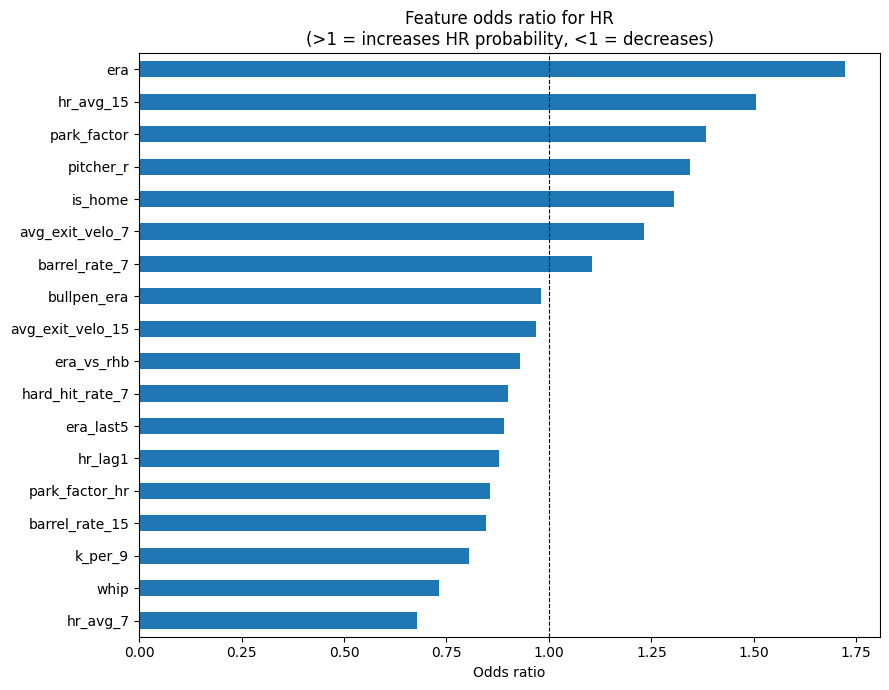


Odds ratios:
hr_avg_7            0.679
whip                0.731
k_per_9             0.806
barrel_rate_15      0.846
park_factor_hr      0.856
hr_lag1             0.877
era_last5           0.890
hard_hit_rate_7     0.901
era_vs_rhb          0.930
avg_exit_velo_15    0.969
bullpen_era         0.980
barrel_rate_7       1.106
avg_exit_velo_7     1.233
is_home             1.305
pitcher_r           1.345
park_factor         1.383
hr_avg_15           1.505
era                 1.722
dtype: float64


In [15]:
# ── Feature coefficients ──
# In logistic regression, exp(coef) = odds ratio
# >1 increases HR probability, <1 decreases it
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Feature odds ratio for HR\n(>1 = increases HR probability, <1 = decreases)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))

In [16]:
# ── Implied odds converter ──
# Converts model probability to American odds
# Compare this to DraftKings line — if book offers better odds, you have edge
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
599 2025-09-04  0.287460           248     ✅ HR
600 2025-09-05  0.130755           665  ❌ No HR
601 2025-09-09  0.045877          2080  ❌ No HR
602 2025-09-10  0.059274          1587  ❌ No HR
603 2025-09-11  0.136997           630  ❌ No HR
604 2025-09-12  0.327310           206  ❌ No HR
605 2025-09-13  0.230726           333  ❌ No HR
606 2025-09-14  0.247840           303     ✅ HR
607 2025-09-16  0.130981           663  ❌ No HR
608 2025-09-17  0.294329           240  ❌ No HR
609 2025-09-18  0.227980           339  ❌ No HR
610 2025-09-19  0.251047           298  ❌ No HR
611 2025-09-20  0.196270           410     ✅ HR
612 2025-09-21  0.051623          1837  ❌ No HR
613 2025-09-23  0.103932           862  ❌ No HR
614 2025-09-24  0.076926          1200  ❌ No HR
615 2025-09-25  0.108287           823  ❌ No HR
616 2025-09-26  0.263238           280  ❌ No HR
617 2025-09-27  0.239640           3

In [17]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/witt_hr_logistic_model.pkl')
joblib.dump(scaler, '../models/witt_hr_logistic_scaler.pkl')
print("Saved:")
print("  models/witt_hr_logistic_model.pkl")
print("  models/witt_hr_logistic_scaler.pkl")

Saved:
  models/witt_hr_logistic_model.pkl
  models/witt_hr_logistic_scaler.pkl
